# Task 5: Personal Loan Acceptance Prediction

## Introduction

The objective of this project is to predict whether a customer is likely to accept a personal loan offer based on demographic and financial information. This project includes data preprocessing, exploratory data analysis (EDA), feature encoding, model training, and evaluation using Logistic Regression.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("Bank_Personal_Loan_Modelling.csv")

In [3]:
df.head()

,ID_Customer,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [4]:
df.shape

(5000, 14)

In [5]:
df.columns

Index(['ID_Customer', 'Age', 'Experience', 'Income', 'ZIP Code', 'Family',
       'CCAvg', 'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_Customer         5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [7]:
df.describe()

,ID_Customer,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [8]:
df.isnull().sum()

,0
ID_Customer,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


## Dataset Understanding

This dataset contains customer demographic and financial information such as age, income, education, family size, mortgage, and banking services. The target variable is **Personal Loan**, which indicates whether a customer accepted a personal loan offer.

In [9]:
# Check missing values

df.isnull().sum()

,0
ID_Customer,0
Age,0
Experience,0
Income,0
ZIP Code,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal Loan,0


In [10]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [11]:
# Remove unnecessary columns

df = df.drop(['ID_Customer', 'ZIP Code'], axis=1)

df.head()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1


## Data Cleaning

The dataset was inspected for missing values and duplicate records. Identification columns (`ID_Customer` and `ZIP Code`) were removed because they do not contribute to predicting whether a customer will accept a personal loan.

## Exploratory Data Analysis (EDA)

EDA was performed to understand customer characteristics and identify factors that influence personal loan acceptance.

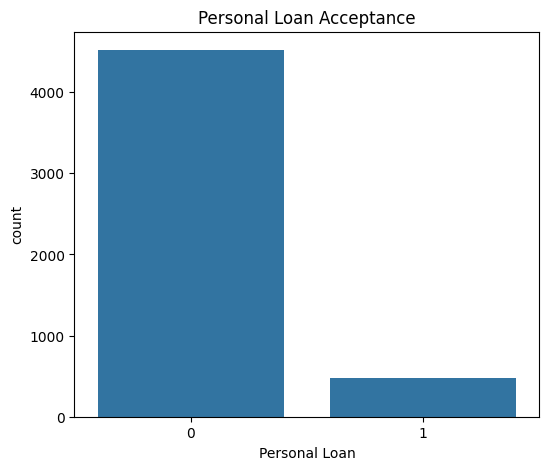

In [12]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Personal Loan'
)

plt.title("Personal Loan Acceptance")

plt.show()

### Observation

Most customers did not accept the personal loan offer, while a smaller proportion accepted it.

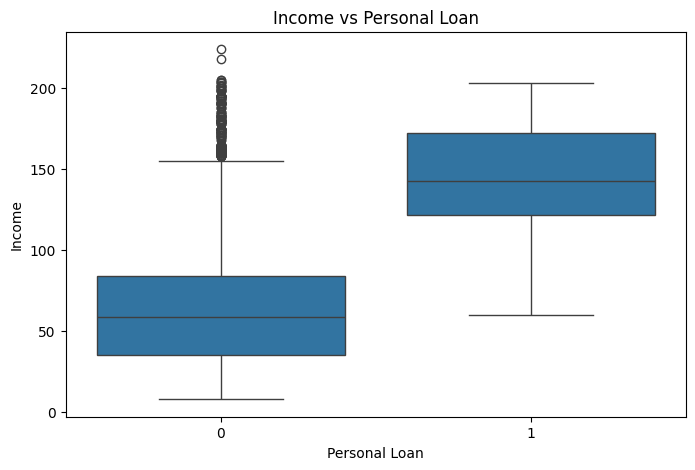

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Personal Loan',
    y='Income'
)

plt.title("Income vs Personal Loan")

plt.show()

### Observation

Customers with higher incomes are more likely to accept a personal loan compared to those with lower incomes.

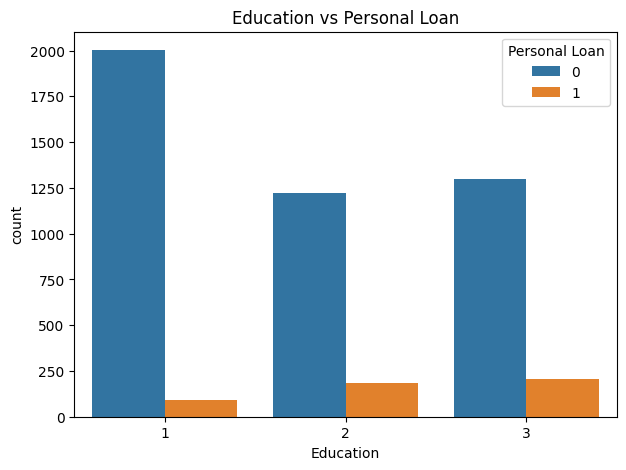

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Education',
    hue='Personal Loan'
)

plt.title("Education vs Personal Loan")

plt.show()

### Observation

Loan acceptance varies across education levels, suggesting that education may influence borrowing decisions.

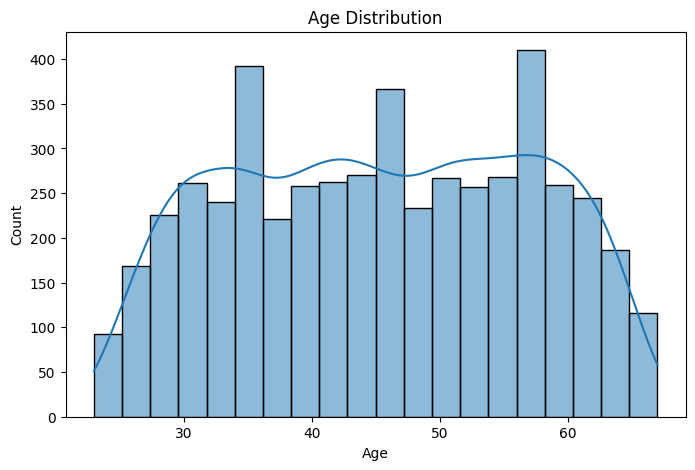

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=20,
    kde=True
)

plt.title("Age Distribution")

plt.show()

### Observation

The age distribution shows that most customers are middle-aged, with fewer customers at the lower and higher ends of the age range.

## Feature Selection

The target variable is **Personal Loan**, while all remaining columns are used as input features for the classification model.

In [16]:
# Features and target

X = df.drop('Personal Loan', axis=1)

y = df['Personal Loan']

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Model Training

A Logistic Regression model was used to classify whether a customer is likely to accept a personal loan offer.

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [19]:
# Predictions

y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.953


### Model Performance

The Logistic Regression model achieved an accuracy of **95.30%**, indicating excellent performance in predicting whether a customer is likely to accept a personal loan. The high accuracy suggests that the selected customer features effectively capture the patterns associated with loan acceptance.

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[883,  12],
       [ 35,  70]])

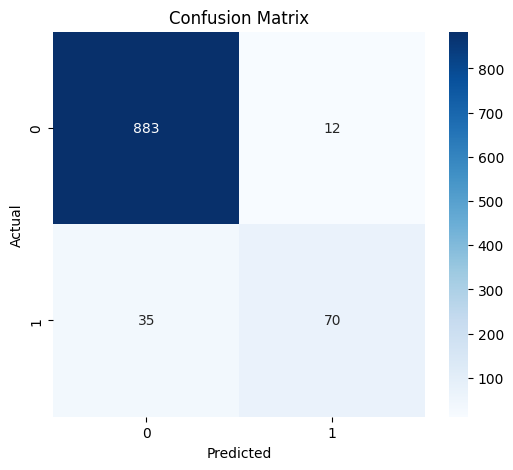

In [22]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       895
           1       0.85      0.67      0.75       105

    accuracy                           0.95      1000
   macro avg       0.91      0.83      0.86      1000
weighted avg       0.95      0.95      0.95      1000



## Conclusion

In this project, a Logistic Regression model was developed to predict whether customers would accept a personal loan offer. The dataset was cleaned by removing unnecessary identification columns, followed by exploratory data analysis to understand customer characteristics. The model was evaluated using Accuracy Score, Confusion Matrix, and Classification Report, demonstrating how machine learning can support customer targeting and banking decisions.